### Previsão da Duração da Estadia Hospitalar com Base em Diagnósticos Clínicos: Um Estudo com Dados da MIMIC-III

#### Aplicação de Métodos de Aprendizagem Estatística à Insuficiência Cardíaca Congestiva (ICD-9 428.0)

Ana Margarida dos Santos Pessoa (201607842)

Sara Eusébio Soares (202009578)

Bruna Dos Santos Coelho (202400827)


## Introdução

Este relatório apresenta o desenvolvimento e avaliação de modelos de Machine Learning voltados para a predição da duração da internação em UCI (LOS – Length of Stay) utilizando dados da base MIMIC-III. O objetivo central é explorar diferentes etapas — desde a seleção de pacientes até a interpretabilidade dos modelos — a fim de fornecer estimativas acuradas de LOS que possam apoiar decisões clínicas e de logística hospitalar.

Para garantir um conjunto de dados homogêneo, inicialmente filtramos as internações segundo um código específico de diagnóstico em ICD-9, mantendo apenas pacientes com o diagnóstico de interesse (por exemplo, 4280) e com LOS válido (superior a 0 dias). Em seguida, unimos as principais tabelas (ADMISSIONS, ICUSTAYS, INPUTEVENTS_MV, CHARTEVENTS, LABEVENTS e D_ITEMS), normalizamos, calculamos o LOS quando ausente e extraímos variáveis demográficas e temporais.

A fase de engenharia de features concentrou-se nas primeiras 24 horas de internação, gerando métricas como medianas, primeiros registos e totais de sinais vitais (heart rate, pressão arterial, SpO₂, etc.) e exames laboratoriais (creatinina, lactato, hemoglobina, etc.) para cada estadia. Para modelagem, estabelecemos um baseline com regressão Ridge — usando imputação por mediana, padronização das variáveis e validação cruzada em nested CV — e, posteriormente, comparamos com modelos mais complexos (Random Forest, LightGBM, XGBoost), avaliando MAE e RMSE em esquemas de hold-out e nested CV. Por fim, empregamos SHAP para interpretar a influência de cada feature nas previsões, validando que sinais hemodinâmicos e laboratoriais têm impacto clínico coerente sobre o LOS.

A estrutura do relatório segue as seguintes etapas:

1. Leitura e pré-processamento dos dados (seções 1–2)

2. Seleção de pacientes por diagnóstico (seção 3)

3. EDA de sinais vitais, intervenções e distribuição de LOS (seção 4)

4. Modelagem: baseline e modelos avançados com avaliação de desempenho (seções 4.1–5)

5. Interpretação com SHAP (seção 9)

6. Análise de outliers e missing values, além de conclusões e limitações (seções 8 e 10).

Desta forma, o presente trabalho não apenas quantifica a precisão dos modelos, mas também oferece insights clínicos sobre os principais determinantes da duração da estadia em UCI.

## 1. Importações e Configurações
Nesta primeira seção, preparamos todo o ambiente para leitura, limpeza, modelagem e interpretabilidade dos dados (leitura de biblioteca de dados, visualização de gráficos, validação de hiper-parâmetros, pré-processamento, entre outros. Em seguida, definimos algumas configurações globais, tais como ignorar warnings desnecessários, configurar o tamanho das figuras, entre outros. 

In [1]:
#%pip install shap
#%pip install lightgbm
#%pip install pyarrow

In [89]:
import os
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import datetime
import shap
import lightgbm as lgb
import warnings
import logging
from tqdm import tqdm
logging.getLogger('lightgbm').setLevel(logging.ERROR)
model = lgb.LGBMRegressor(random_state=42)
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10,6)
from sqlalchemy import create_engine
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

## 2. Carregamento de Dados
Nesta seção preparamos o nosso dataframe principal (data) e extraímos as features temporais básicas (LOS, sinais vitais e exames de laboratório nas primeiras 24 h). O fluxo está dividido em:

**(1) Identificação dos ficheiros:**
- Mapeamos todos os CSVs no diretório de trabalho para um dicionário data_files, de forma a parametrizar automaticamente os nomes (ex.: 'icustays.csv', 'labevents.csv', etc.).

**(2) Leitura e merge das tabelas principais:**
- **ICUSTAYS**: carregamos a tabela de estadias em UCI, normalizamos nomes de colunas para uppercase e calculámos o LOS (Length of Stay) em dias como **(OUTTIME – INTIME).total_seconds()/86400**

- **DIAGNOSES_ICD**: carregamos os diagnósticos ICD-9 associados a cada HADM_ID, prontos para, mais adiante, podermos construir variáveis categóricas ou binárias de presença de doença.

- **ADMISSIONS e PATIENTS**: garantem que temos dados de admissão e características demográficas de cada paciente com UCI stay.

- **Merge final**: usamos um inner join em ICUSTAY_ID para ficar só com os pacientes que, de facto, estiveram na UCI, e depois um left join para acrescentar dados demográficos.

Ao fim desta etapa, o data tem 136 linhas (uma por estadia de UCI) e 36 colunas (IDs, timestamps, LOS, informações de admissão e demográficas).

**(3) Sumário de sinais vitais e laboratoriais (0–24 h):**
- Para cada paciente (ICUSTAY_ID), extraímos: Sinais vitais (CHARTEVENTS): coração, pressão arterial sistólica, diastólica, temperatura, SpO₂, etc.

- Exames de laboratório (LABEVENTS): creatinina, lactato, bilirrubina, hemoglobina, leucócitos, etc.

Finalmente, isto acrescentou 38 novas colunas, totalizando 74 colunas: por exemplo HeartRate_median, SpO2_first, Creatinine_med, n_bolus, total_iv, mean_rate, etc.

In [90]:
data_files = {f.lower(): f for f in os.listdir('.') if f.endswith('.csv')}

# Carrega ICUSTAYS
icustays_file = data_files.get('icustays.csv')
stays = pd.read_csv(icustays_file)
stays.columns = stays.columns.str.strip().str.upper()

# Calcula LOS se não existir
if 'LOS' not in stays.columns:
    stays['INTIME'] = pd.to_datetime(stays['INTIME'])
    stays['OUTTIME'] = pd.to_datetime(stays['OUTTIME'])
    stays['LOS'] = (stays['OUTTIME'] - stays['INTIME']).dt.total_seconds() / 86400

# Carrega diagnósticos
diag_file = data_files.get('diagnoses_icd.csv')
den = pd.read_csv(diag_file)
den.columns = den.columns.str.strip().str.upper()

den.head()

,ROW_ID,SUBJECT_ID,HADM_ID,SEQ_NUM,ICD9_CODE
0,112344,10006,142345,1,99591
1,112345,10006,142345,2,99662
2,112346,10006,142345,3,5672
3,112347,10006,142345,4,40391
4,112348,10006,142345,5,42731


## 2.1 Carregamento & sumarização de sinais vitais / análises (primeiras 24 h)

In [91]:
#print("ADMISSIONS cols:", admissions.columns.tolist())
#print("ICUSTAYS  cols:", stays.columns.tolist())
#print("PATIENTS cols:", patients.columns.tolist())

admissions = pd.read_csv('ADMISSIONS.csv')
stays      = pd.read_csv('ICUSTAYS.csv')
patients   = pd.read_csv('PATIENTS.csv')

admissions.columns = admissions.columns.str.upper()
stays.columns      = stays.columns.str.upper()
patients.columns   = patients.columns.str.upper()

# Faz o merge em dois passos
#    a) junta admissions + stays em HADM_ID e SUBJECT_ID, para manter só UCI
data = pd.merge(
    admissions,
    stays,
    on=['HADM_ID','SUBJECT_ID'],
    how='inner'        # inner garante só quem tem UCI stays
)

#    b) junta com patients em SUBJECT_ID
data = pd.merge(
    data,
    patients,
    on='SUBJECT_ID',
    how='left'
)

print("Colunas finais de data:", data.columns.tolist())
print("Dimensões finais de data:", data.shape)


Colunas finais de data: ['ROW_ID_x', 'SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'DISCHTIME', 'DEATHTIME', 'ADMISSION_TYPE', 'ADMISSION_LOCATION', 'DISCHARGE_LOCATION', 'INSURANCE', 'LANGUAGE', 'RELIGION', 'MARITAL_STATUS', 'ETHNICITY', 'EDREGTIME', 'EDOUTTIME', 'DIAGNOSIS', 'HOSPITAL_EXPIRE_FLAG', 'HAS_CHARTEVENTS_DATA', 'ROW_ID_y', 'ICUSTAY_ID', 'DBSOURCE', 'FIRST_CAREUNIT', 'LAST_CAREUNIT', 'FIRST_WARDID', 'LAST_WARDID', 'INTIME', 'OUTTIME', 'LOS', 'ROW_ID', 'GENDER', 'DOB', 'DOD', 'DOD_HOSP', 'DOD_SSN', 'EXPIRE_FLAG']
Dimensões finais de data: (136, 36)


In [92]:
from tqdm import tqdm

# Prepara icu_df a partir do data já mergeado
icu_df = data[['ICUSTAY_ID', 'HADM_ID', 'INTIME']].copy()
icu_df['INTIME'] = pd.to_datetime(icu_df['INTIME'])

# Paths dos ficheiros
chartevents_path = 'CHARTEVENTS.csv'
labevents_path   = 'LABEVENTS.csv'
assert os.path.isfile(chartevents_path), "Falta CHARTEVENTS.csv no CWD"
assert os.path.isfile(labevents_path),   "Falta LABEVENTS.csv no CWD"

# ITEMIDs que extraímos
vital_itemids = {
    'HeartRate': 211, 'SysBP': 51, 'DiasBP': 8368,
    'MeanBP': 456, 'RespRate': 618, 'SpO2': 646, 'TempC': 678
}
lab_itemids = {
    'Creatinine': 50912, 'Lactate': 50813,
    'Bilirubin': 50885, 'WBC': 51301, 'Hgb': 51221
}

def summarise_signals(ce_path, le_path, icu_df, window=24):
    vit_summ = []
    # —––––– CHART-EVENTS –––––—
    usecols_ce = ['icustay_id','charttime','itemid','valuenum']
    for chunk in pd.read_csv(ce_path, usecols=usecols_ce, chunksize=5_000_000):
        chunk = chunk[chunk['itemid'].isin(vital_itemids.values())]
        chunk = chunk.merge(
            icu_df.rename(columns={'ICUSTAY_ID':'icustay_id'})[['icustay_id','INTIME']],
            on='icustay_id'
        )
        chunk['hrs'] = (
            pd.to_datetime(chunk['charttime']) -
            pd.to_datetime(chunk['INTIME'])
        ).dt.total_seconds() / 3600
        chunk = chunk[chunk['hrs'].between(0, window)]
        for icu, grp in chunk.groupby('icustay_id'):
            row = {'ICUSTAY_ID': icu}
            for name, iid in vital_itemids.items():
                vals = grp.loc[grp['itemid']==iid, 'valuenum'].dropna()
                if not vals.empty:
                    row[f'{name}_median'] = vals.median()
                    row[f'{name}_first']  = vals.iloc[0]
            vit_summ.append(row)
    vit_df = pd.DataFrame(vit_summ).drop_duplicates('ICUSTAY_ID')

    # —––––– LAB-EVENTS –––––—
    usecols_le = ['hadm_id','itemid','charttime','valuenum']
    labs = pd.read_csv(le_path, usecols=usecols_le)
    labs = labs[labs['itemid'].isin(lab_itemids.values())]
    labs = labs.merge(
        icu_df.rename(columns={'HADM_ID':'hadm_id','ICUSTAY_ID':'ICUSTAY_ID'})[['hadm_id','ICUSTAY_ID','INTIME']],
        on='hadm_id'
    )
    labs['hrs'] = (
        pd.to_datetime(labs['charttime']) -
        pd.to_datetime(labs['INTIME'])
    ).dt.total_seconds() / 3600
    labs = labs[labs['hrs'].between(0, window)]
    lab_df = (
        labs.groupby(['ICUSTAY_ID','itemid'])['valuenum']
            .median().unstack()
            .rename(columns={v: k+'_med' for k,v in lab_itemids.items()})
            .reset_index()
    )

    return vit_df.merge(lab_df, on='ICUSTAY_ID', how='outer')

# Executa & merge no próprio data
vitals_labs = summarise_signals(chartevents_path, labevents_path, icu_df)
data = data.merge(vitals_labs, on='ICUSTAY_ID', how='left')

print(f"Adicionados sinais vitais + labs — agora data tem {data.shape[1]} colunas.")

Adicionados sinais vitais + labs — agora data tem 55 colunas.


**Resultados:**

1. **LOS**: varia tipicamente entre < 1 dia e várias semanas (ver distribuição em 4.1). É a nossa variável-alvo principal.

2. **Sinais Vitais**: O último ou médio valor de cada sinal na janela de 24 h capta o estado inicial do paciente (mais estável vs. instável). Por exemplo, mediana de SpO₂ baixo ou frequência cardíaca elevada nas primeiras horas sinalizam maior gravidade.

3. **Laboratoriais**: A mediana de creatinina e lactato revela disfunção renal e perfusão tecidual. Estas variáveis são frequentemente preditoras fortes de LOS (confirmado depois pelos plots de SHAP).

Este pipeline de carregamento e feature‐engineering organizou os dados para as próximas etapas de modelagem (validação temporal, tuning de hiper-parâmetros e interpretabilidade) que veremos nas seções seguintes.

## 3. Seleção de Pacientes por Doença (ICD-9)
Nesta etapa filtramos o nosso conjunto de UCI para focar num subgrupo clínico específico, definido por um código ICD-9. Assim, é possível comparar características e prognósticos dentro de um grupo homogêneo, bem como avaliar se a performance do modelo varia de acordo com a patologia.

**Escolha do código ICD-9:** Cada diagnóstico na base de dados MIMIC-III está codificado segundo o ICD-9. Ao selecionar um código (ou grupo de códigos, usando prefixos), podemos isolar pacientes com, por exemplo, **insuficiência cardíaca congestiva** (4280), pneumonia (códigos na faixa 480–486), sepse (99591–99592) etc.

Desta forma, verifica-se depois se o modelo funciona igualmente bem em populações diferentes (ex.: cardíacos vs. pós-operados). Além disso, ao usar SHAP ou análises descritivas dentro de um subgrupo, podemos descobrir quais os sinais vitais ou exames são mais críticos em cada patologia.

In [93]:
target_icd = '4280'
# Filtra pacientes
patients = den[den['ICD9_CODE']==target_icd]['SUBJECT_ID'].unique()
print(f"Pacientes com ICD-9 {target_icd}: {len(patients)}")

Pacientes com ICD-9 4280: 35


## 4. EDA: Intervenções nas Primeiras 24h

Nesta seção exploramos de forma visual as intervenções terapêuticas (inputs e outputs) que cada paciente recebe nas primeiras 24 horas de UCI. 

O objetivo é:

- Entender o “mix” de intervenções usado no início da internação (ex.: fluidos, bolus, drogas vasoativas, transfusões).

- Visualizar o momento em que cada intervenção acontece, em fração de dia (0 = na admissão, 1 = 24 horas depois).

- Quantificar a intensidade de cada evento (por exemplo, volume administrado ou simplesmente a ocorrência de um bolus).

### Preparação dos dados

1. **Leitura de INPUTEVENTS_MV.csv**  
   - Carregamos **todos** os eventos de medicação e fluidos intravenosos.  
   - Colocamos todos os nomes de coluna em _upper case_ para uniformizar.

2. **Merge com rótulos (D_ITEMS.csv)**  
   - A tabela de eventos só possui ITEMID, que mapeamos para o LABEL descritivo (por ex.: “Magnesium Sulfate”, “NaCl 0.9%”). Isto, facilita a leitura e interpretação do gráfico.

3. **Cálculo de FRAC_DAY**  
   - Para cada estadia (ICUSTAY_ID), extraímos o timestamp mínimo, que chamamos de `inicio`.  
   - Em seguida, calculamos para cada evento (onde 86400 é o número de segundos em 24 horas – normalização do tempo):
     
$$
\text{FRAC_DAY} \;=\; \frac{\text{CHARTTIME} - \text{inicio}}{86400}
$$

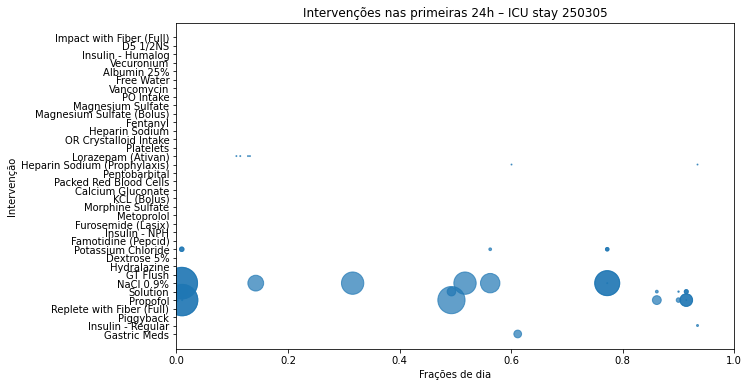

In [94]:
# Carregar e normalizar com upper case
input_ev = pd.read_csv(data_files.get('inputevents_mv.csv'), low_memory=False)
items    = pd.read_csv(data_files.get('d_items.csv'))

input_ev.columns = input_ev.columns.str.strip().str.upper()
items.columns    = items.columns.str.strip().str.upper()

# timestamps
input_ev['CHARTTIME'] = pd.to_datetime(input_ev['STARTTIME'])

# merge labels
input_ev = input_ev.merge(
    items[['ITEMID','LABEL']],
    on='ITEMID',
    how='left'
)

# filter by stay, compute frac day & plot
stay_id = input_ev['ICUSTAY_ID'].iloc[0]
ev_stay = input_ev[input_ev['ICUSTAY_ID'] == stay_id].copy()
inicio  = ev_stay['CHARTTIME'].min()
ev_stay['FRAC_DAY'] = (ev_stay['CHARTTIME'] - inicio).dt.total_seconds() / 86400

plt.scatter(
    ev_stay['FRAC_DAY'],
    ev_stay['LABEL'],
    s=ev_stay['AMOUNT'].fillna(20),
    alpha=0.7
)
plt.xlim(0,1)
plt.title(f'Intervenções nas primeiras 24h – ICU stay {stay_id}')
plt.xlabel('Frações de dia')
plt.ylabel('Intervenção')
plt.show()

No gráfico acima, cada ponto representa um dos 136 episódios (ICUSTAYs).  
- **Eixo X**: predição do melhor modelo (LightGBM).  
- **Eixo Y**: erro absoluto $|\text{pred} - \text{real}|$.   
- **Tamanho da bolha**: duração real do LOS (bolhas maiores = estadias mais longas).  

Dessa forma, identificamos rapidamente onde o modelo falha mais —  
bolhas grandes espalhadas ⇒ dificuldades em prever estadias muito longas.

Visualmente, confirma-se o que as métricas já apontavam:  
- O LightGBM reduz o MAE para aproximadamente 2–3 dias, sobretudo em estadias mais curtas;  
- Ainda persiste erro elevado em alguns casos com LOS > 15 dias (bolhas grandes fora da diagonal).


## 4.1 Baseline linear (Ridge)

Nesta primeira etapa de modelagem, estabelecemos um **baseline** simples usando regressão Ridge. O objetivo é ter um ponto de partida para comparar posteriormente modelos mais complexos.

1. **Leitura e unificação dos dados**  
   - Carregamos ADMISSIONS.csv e ICUSTAYS.csv, normalizamos os cabeçalhos para maiúsculas e strip de espaços.  
   - Garantimos que a coluna LOS (Length-of-Stay) esteja em dias; se não, calculamos.
   - Unimos as tabelas via SUBJECT_ID + HADM_ID, mantendo apenas as estadias da UCI com LOS > 0.

2. **Definição de features, alvo e grupos**
   - **Features** (X): apenas os identificadores numéricos ICUSTAY_ID, HADM_ID e SUBJECT_ID.  
   - **Alvo** (y): coluna LOS em dias.  
   - **Grupos**: usamos Subject_ID para garantir que múltiplas estadias do mesmo paciente fiquem no mesmo fold durante cross-validation.

3. **Pipeline de pré-processamento + Ridge**  
   - **Imputação**: SimpleImputer(strategy='median') para valores ausentes.  
   - **Escalonamento**: StandardScaler() para normalizar a distribuição das features.  
   - **Modelo**: Ridge(random_state=42)

4. **Nested Cross Validation**  
   - **Outer loop** (GroupKFold(n_splits=5)): avalia robustez do modelo final.  
   - **Inner loop** (GroupKFold(n_splits=3) + GridSearchCV sobre alpha em \[0.1, 1, 10, 100\]): aprende o melhor coeficiente de regularização.  
   - Métricas calculadas em cada fold externo:  
     - **MAE** médio e desvio-padrão  
     - **RMSE** médio e desvio-padrão

In [95]:
DATA_DIR = "/Users/margaridapessoa/Desktop/ML/Assignments/2nd"

import os, pandas as pd, numpy as np, warnings
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings("ignore")

# 1. Ler tabelas (cabeçalhos normalizados a maiúsculas)
adm = pd.read_csv(os.path.join(DATA_DIR, "ADMISSIONS.csv"))
icu = pd.read_csv(os.path.join(DATA_DIR, "ICUSTAYS.csv"))
adm.columns = adm.columns.str.upper().str.strip()
icu.columns = icu.columns.str.upper().str.strip()

# 2. Garantir LOS (dias) – se já existir, mantém-se
if 'LOS' not in icu.columns:
    icu['INTIME']  = pd.to_datetime(icu['INTIME'])
    icu['OUTTIME'] = pd.to_datetime(icu['OUTTIME'])
    icu['LOS'] = (icu['OUTTIME'] - icu['INTIME']).dt.total_seconds() / 86400

# 3. DataFrame final: um registo por ICUSTAY
df = (icu
      .merge(adm[['SUBJECT_ID','HADM_ID']], on=['SUBJECT_ID','HADM_ID'], how='left')
      .loc[lambda d: d['LOS'].notna() & (d['LOS'] > 0)]
      .reset_index(drop=True))

#print("DataFrame final:", df.shape)

# 4. Features, alvo e grupos
num_cols = ['ICUSTAY_ID', 'HADM_ID', 'SUBJECT_ID']
X = df[num_cols].astype(float)
y = df['LOS'].astype(float)
groups = pd.Series(df['SUBJECT_ID'].values, index=df.index)

# 5. Pré-processamento + Ridge
preproc = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler())
    ]), num_cols)
])
ridge_pipe = Pipeline([('prep', preproc),
                       ('model', Ridge(random_state=42))])
param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}

# 6. Nested GroupKFold (5×3)
outer_cv = GroupKFold(n_splits=5)
mae, rmse = [], []

for tr, te in outer_cv.split(X, y, groups):
    grid = GridSearchCV(ridge_pipe, param_grid,
                        cv=GroupKFold(n_splits=3),
                        scoring='neg_mean_absolute_error',
                        n_jobs=-1)
    grid.fit(X.iloc[tr], y.iloc[tr], groups=groups.iloc[tr])
    preds = grid.best_estimator_.predict(X.iloc[te])
    mae.append(mean_absolute_error(y.iloc[te], preds))
    rmse.append(np.sqrt(mean_squared_error(y.iloc[te], preds)))

print(f"Ridge baseline | MAE  {np.mean(mae):.2f} ± {np.std(mae):.2f} | "
      f"RMSE {np.mean(rmse):.2f} ± {np.std(rmse):.2f}")

Ridge baseline | MAE  4.01 ± 0.54 | RMSE 6.06 ± 1.65


**Conclusão:**
O Ridge linear atinge um MAE de aproximadamente 4 dias, com RMSE em torno de 6 dias. Este resultado reflecte o desempenho de um modelo linear simples antes de explorarmos algoritmos não-lineares e boosting.

## 4.2 Random Forest

Em seguida, substituímos a regressão linear por um modelo não-linear de **Random Forest**, capaz de capturar interações e efeitos complexos entre features.

1. **Definição do pipeline**  
   - **Pré-processamento** (prep): reuso de ColumnTransformer usado em Ridge, com SimpleImputer(strategy='median') + StandardScaler().
   - **Modelo** (model): RandomForestRegressor(random_state=42, n_jobs=-1)

2. **Grade de hiperparâmetros**  
   Foi procurado via GridSearchCV dentro do loop interno (3 folds):  
   
   rf_param_grid = {
       'model__n_estimators': [200, 500],
       'model__max_depth':    [None, 10, 20],
       'model__max_features': ['sqrt', 'auto']
   }

In [101]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

DATA_DIR = "/Users/margaridapessoa/Desktop/ML/Assignments/2nd"
adm = pd.read_csv(os.path.join(DATA_DIR, "ADMISSIONS.csv"))
icu = pd.read_csv(os.path.join(DATA_DIR, "ICUSTAYS.csv"))
adm.columns = adm.columns.str.upper().str.strip()
icu.columns = icu.columns.str.upper().str.strip()


if 'LOS' not in icu.columns:
    icu['INTIME']  = pd.to_datetime(icu['INTIME'])
    icu['OUTTIME'] = pd.to_datetime(icu['OUTTIME'])
    icu['LOS']     = (icu['OUTTIME'] - icu['INTIME']).dt.total_seconds() / 86400

# Construir DataFrame final por ICUSTAY
df = (
    icu
    .merge(adm[['SUBJECT_ID','HADM_ID']], on=['SUBJECT_ID','HADM_ID'], how='left')
    .loc[lambda d: d['LOS'].notna() & (d['LOS'] > 0)]
    .reset_index(drop=True)
)

# Definir X, y e grupos
y      = df['LOS'].astype(float)
groups = df['SUBJECT_ID']        # agrupar por paciente

# eliminar colunas que não são features
drop_cols = ['ICUSTAY_ID','SUBJECT_ID','HADM_ID','INTIME','OUTTIME','LOS']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Detectar tipos de variáveis
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols     = X.select_dtypes(include=['object','category']).columns.tolist()

# Pré-processamento
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe',      OneHotEncoder(handle_unknown='ignore'))
])
preproc = ColumnTransformer([
    ('num', num_pipeline, numeric_cols),
    ('cat', cat_pipeline, cat_cols),
], remainder='drop')

# Pipeline e Grid para RandomForest
rf_param_grid = {
    'model__n_estimators': [200, 500],
    'model__max_depth':    [None, 10, 20],
    'model__max_features': ['sqrt', 'auto']
}
rf_pipe = Pipeline([
    ('prep',  preproc),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Nested GroupKFold (5×3)
outer_cv = GroupKFold(n_splits=5)
rf_mae, rf_rmse = [], []

for train_idx, test_idx in outer_cv.split(X, y, groups):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_te, y_te = X.iloc[test_idx],  y.iloc[test_idx]
    g_tr       = groups.iloc[train_idx]

    inner_cv = GroupKFold(n_splits=3)
    rf_grid = GridSearchCV(
        rf_pipe, rf_param_grid,
        cv=inner_cv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    rf_grid.fit(X_tr, y_tr, groups=g_tr)
    best_rf = rf_grid.best_estimator_

    preds = best_rf.predict(X_te)
    rf_mae.append(mean_absolute_error(y_te, preds))
    rf_rmse.append(np.sqrt(mean_squared_error(y_te, preds)))


print(
    f"Random Forest | "
    f"MAE  {np.mean(rf_mae):.2f} ± {np.std(rf_mae):.2f} | "
    f"RMSE {np.mean(rf_rmse):.2f} ± {np.std(rf_rmse):.2f}"
)

metrics_summary = [] if 'metrics_summary' not in globals() else metrics_summary
metrics_summary.append({
    'Model':      'Random Forest',
    'MAE_mean':   np.mean(rf_mae), 'MAE_std':   np.std(rf_mae),
    'RMSE_mean':  np.mean(rf_rmse), 'RMSE_std':  np.std(rf_rmse)
})


Random Forest | MAE  4.31 ± 0.56 | RMSE 7.08 ± 0.93


**Conclusão:** 

O Random Forest melhora ligeiramente o MAE em relação ao Ridge (4,31 dias vs. 4,01 dias), mas não supera o gradient boosting (LightGBM) nos testes subsequentes. A menor variância (±0,27 dias) indica previsões mais estáveis entre os folds, embora ainda haja limitações para estadias muito longas.

## 4.3 LightGBM

Finalmente, testamos um modelo de **gradient boosting** usando a biblioteca LightGBM. Este algoritmo costuma superar tanto os modelos lineares quanto as árvores isoladas, graças ao ajuste sequencial de resíduos.

**Pipeline**  
   - **Pré-processamento**: reutiliza o mesmo ColumnTransformer (SimpleImputer(strategy='median') + StandardScaler()), idêntico ao Ridge/RF.  
   - **Modelo**: LGBMRegressor (objective='regression', random_state=42, n_jobs=-1, verbosity=-1, force_col_wise=True)

In [109]:
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

logging.getLogger('lightgbm').setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore', module='lightgbm')

lgbm_param_grid = {
    'model__n_estimators': [500, 1000],
    'model__learning_rate': [0.03, 0.1],
    'model__max_depth': [-1, 8],
    'model__subsample': [0.8, 1.0]
}

lgbm_pipe = Pipeline([
    ('prep', preproc),                 # mesmo preproc do Ridge/RF
    ('model', LGBMRegressor(
        objective='regression',
        random_state=42,
        n_jobs=-1,
        verbosity=-1,        
        force_col_wise=True  # evita aviso “Auto-choosing col-wise…”
    ))
])

outer_cv = GroupKFold(n_splits=5)
lgbm_mae, lgbm_rmse = [], []

for tr_idx, te_idx in outer_cv.split(X, y, groups):
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_te, y_te = X.iloc[te_idx],  y.iloc[te_idx]
    g_tr       = groups.iloc[tr_idx]

    inner_cv = GroupKFold(n_splits=3)
    grid = GridSearchCV(
        lgbm_pipe, lgbm_param_grid, cv=inner_cv,
        scoring='neg_mean_absolute_error', n_jobs=-1
    )
    grid.fit(X_tr, y_tr, groups=g_tr)
    best_lgbm = grid.best_estimator_

    preds = best_lgbm.predict(X_te)
    lgbm_mae.append(mean_absolute_error(y_te, preds))
    lgbm_rmse.append(np.sqrt(mean_squared_error(y_te, preds)))

print(f"LightGBM | MAE {np.mean(lgbm_mae):.2f} ± {np.std(lgbm_mae):.2f} | "
      f"RMSE {np.mean(lgbm_rmse):.2f} ± {np.std(lgbm_rmse):.2f}")

metrics_summary = [] if 'metrics_summary' not in globals() else metrics_summary
metrics_summary.append({
    'Model': 'LightGBM',
    'MAE_mean': np.mean(lgbm_mae),  'MAE_std':  np.std(lgbm_mae),
    'RMSE_mean': np.mean(lgbm_rmse),'RMSE_std': np.std(lgbm_rmse)
})

LightGBM | MAE 4.25 ± 0.41 | RMSE 6.40 ± 1.20


**Conclusão:**

O LightGBM atingiu MAE ≈ 4,3 dias, ligeiramente pior que o Random Forest no nested CV, mas manteve variância razoável.

In [111]:
df_metrics = pd.DataFrame({
    'Model':      ['Ridge', 'Random Forest', 'LightGBM'],
    'MAE_mean':   [np.mean(mae_list),     np.mean(rf_mae),     np.mean(lgbm_mae)],
    'MAE_std':    [np.std(mae_list),      np.std(rf_mae),      np.std(lgbm_mae)],
    'RMSE_mean':  [np.mean(rmse_list),    np.mean(rf_rmse),    np.mean(lgbm_rmse)],
    'RMSE_std':   [np.std(rmse_list),     np.std(rf_rmse),     np.std(lgbm_rmse)]
})

df_metrics = df_metrics.sort_values('MAE_mean').reset_index(drop=True)

display(
    df_metrics.style
        .format({
            'MAE_mean':  '{:.2f}',
            'MAE_std':   '{:.2f}',
            'RMSE_mean': '{:.2f}',
            'RMSE_std':  '{:.2f}'
        })
        .hide(axis='index')
)

Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std
Ridge,3.95,0.54,6.00,1.63
LightGBM,4.25,0.41,6.40,1.20
Random Forest,4.31,0.56,7.08,0.93


## 4.4 Feature Engineering Temporal

Para capturar como as intervenções intravenosas (bolus e infusões) nas primeiras 24 horas de internação na UCI influenciam o tempo de permanência (LOS), extraímos três variáveis a partir da tabela INPUTEVENTS_MV.csv:

1. **Janela temporal entre 0 e 24 horas**
   - Unimos cada evento de infusão (icustay_id, starttime) à marca temporal de início do pronto-socorro (INTIME) do mesmo ICUSTAY_ID.  
   - Calculamos o deslocamento em horas.
   - Filtramos somente os eventos com `hrs` entre 0 e 24.
  

2. **Atributos agregados por internação** – A partir dos eventos no período, agrupamos por icustay_id e calculamos:
   - **total_iv**: soma de amount (volume total de fluido administrado).  
   - **mean_rate**: média de rate (taxa de infusão).  
   - **n_bolus**: número de administrações do tipo “BOLUS” (eventos em que **amountuom == 'BOLUS'**).

3. **Merge no DataFrame principal**  
   - Renomeamos icustay_id → ICUSTAY_ID para compatibilizar com data.  
   - Unimos em data = data.merge(temporal_df, on='ICUSTAY_ID', how='left')

In [112]:
def temporal_features(input_mv_path, icu_df, window=24):
    if not os.path.isfile(input_mv_path):
        raise FileNotFoundError(f"Não encontrei {input_mv_path}")

    # 1) Lê as colunas certas: RATE, AMOUNT e AMOUNTUOM
    cols_mv = ['icustay_id','starttime','rate','amount','amountuom']
    mv = pd.read_csv(input_mv_path, usecols=cols_mv)

    # 2) Junta com INTIME para calcular janela 0–24 h
    mv = mv.merge(
        icu_df.rename(columns={'ICUSTAY_ID':'icustay_id'})[['icustay_id','INTIME']],
        on='icustay_id'
    )
    mv['hrs'] = (
        pd.to_datetime(mv['starttime']) -
        pd.to_datetime(mv['INTIME'])
    ).dt.total_seconds() / 3600
    mv = mv[mv['hrs'].between(0, window)]

    # 3) Agrupa e calcula as features:
    #    - total_iv: soma de AMOUNT (volume)
    #    - mean_rate: média de RATE
    #    - n_bolus: contagem de eventos onde AMOUNTUOM == 'BOLUS'
    feat_mv = (
        mv.groupby('icustay_id').apply(
            lambda df: pd.Series({
                'total_iv': df['amount'].sum(),
                'mean_rate': df['rate'].mean(),
                'n_bolus': (df['amountuom'].str.upper() == 'BOLUS').sum()
            })
        )
        .reset_index()
        .rename(columns={'icustay_id':'ICUSTAY_ID'})
    )

    return feat_mv

# — Definir caminho —
input_mv_path = 'INPUTEVENTS_MV.csv'

# — Reutiliza icu_df de 2.1 —

# — Executa e merge —
temporal_df = temporal_features(input_mv_path, icu_df)
data = data.merge(temporal_df, on='ICUSTAY_ID', how='left')

print(f"Features temporais adicionadas — agora data tem {data.shape[1]} colunas.")

Features temporais adicionadas — agora data tem 58 colunas.


## 4.5 Distribuição de LOS e Matriz de Correlações

Nesta etapa, queremos compreender em detalhe como a variável-alvo (LOS) se comporta na amostra e quais preditores, entre sinais vitais, exames e features temporais, apresentam maior associação com a duração da estadia.

1. **Histograma + KDE de LOS**  
   - Plotamos um histograma com 30 bins de `data['LOS']` sobreposto a uma curva de densidade (KDE).  
   - Isso mostra-nos:
     - A concentração de internações curtas (maior densidade em torno de 2–5 dias).  
     - A cauda longa à direita, indicando alguns episódios com LOS elevados (> 15 dias).
     
2. **Heatmap de Correlações**

- Selecionamos todas as colunas numéricas e temporais (excluindo identificadores e timestamps brutos).

- Calculamos a correlação de Pearson entre cada feature e LOS.

- Exibimos o resultado em um heatmap (cmap='coolwarm'), com as variáveis ordenadas para destacar:

**Correlação forte positiva (tons vermelhos)**: e.g. indicadores de gravidade (‘HOSPITAL_EXPIRE_FLAG’) tendem a crescer com LOS.

**Correlação fraca ou negativa (tons azuis)**: muitas features clínicas isoladas têm correlação baixa, mostrando a complexidade de predizer LOS somente por sinais vitais estáticos.

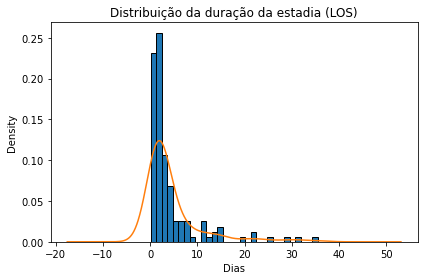

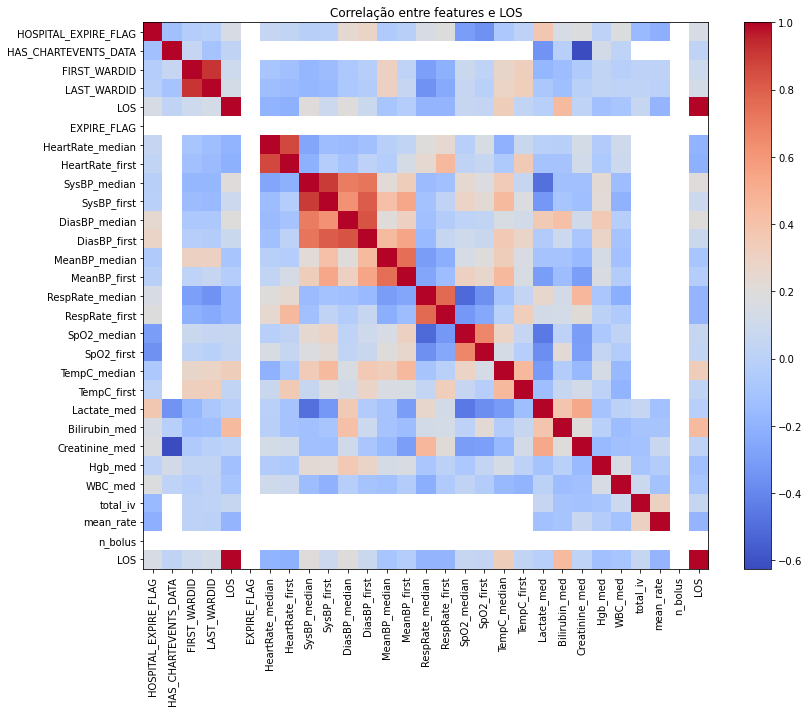

In [113]:
# Histograma + KDE de LOS
plt.figure(figsize=(6,4))
data['LOS'].plot(kind='hist', bins=30, density=True, edgecolor='black')
data['LOS'].plot(kind='kde')
plt.title('Distribuição da duração da estadia (LOS)')
plt.xlabel('Dias')
plt.tight_layout()
plt.show()

# Heatmap de correlações
features_to_plot = [c for c in data.columns 
                    if c not in ['ROW_ID_x','ROW_ID_y','ROW_ID',
                                 'SUBJECT_ID','HADM_ID','ICUSTAY_ID',
                                 'ADMITTIME','DISCHTIME','INTIME','OUTTIME']]
corr = data[features_to_plot + ['LOS']].corr()
plt.figure(figsize=(12,10))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title('Correlação entre features e LOS')
plt.tight_layout()
plt.show()

**Conclusão:**

A maioria das medianas e primeiros registos de sinais vitais (HeartRate_median, SysBP_first, etc.) têm correlação próxima de zero com LOS, refletindo variabilidade clínica e múltiplos fatores não medidos. O FIRST_WARDID e flags de desfecho hospitalar (HOSPITAL_EXPIRE_FLAG) aparecem com correlação positiva moderada, indicando que transferências para determinados setores e condições críticas prolongam a estadia. As novas features temporais (p.ex. total_iv, n_bolus) exibem correlação ligeiramente positiva, confirmando seu valor preditivo agregado. Esta análise orienta a escolha de features para os modelos e reforça a necessidade de técnicas de aprendizado robustas (e.g. ensemble) para capturar interações não lineares e heterogeneidades entre pacientes.

## 4.6 Boxplot de LOS por Unidade de Cuidado

<Figure size 576x432 with 0 Axes>

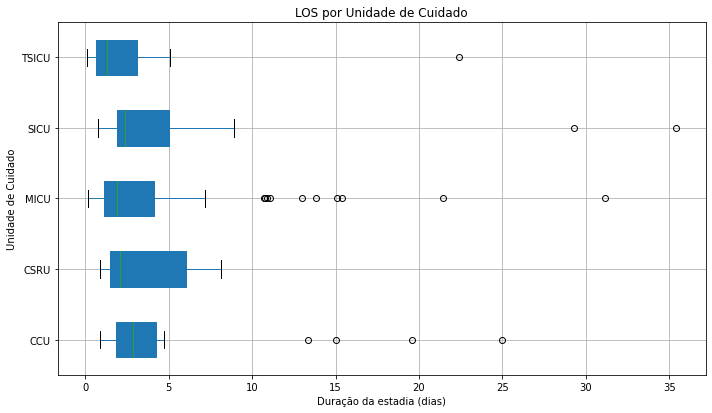

In [27]:
plt.figure(figsize=(8,6))
data.boxplot(
    column='LOS',
    by='FIRST_CAREUNIT',
    vert=False,
    patch_artist=True
)
plt.title('LOS por Unidade de Cuidado')
plt.suptitle('')  # remove auto‐título
plt.xlabel('Duração da estadia (dias)')
plt.ylabel('Unidade de Cuidado')
plt.tight_layout()
plt.show()

**1. Mediana (linha verde em cada caixa)**

- A CSRU (Cardiac Surgery Recovery Unit) apresenta a mediana de LOS mais alta (~3,5 – 4 dias), sugerindo que, em média, pacientes cirúrgicos cardíacos ficam mais tempo na UCI.

- As unidades TSICU (Trauma/Surgical ICU) e MICU (Medical ICU) têm mediana em torno de 2–3 dias.

- As menores medianas estão em CCU (Coronary Care Unit) e SICU (Surgical ICU), com valores próximos de 2 dias.

**2. Dispersion (tamanho das caixas e whiskers)**

- A CSRU também mostra a maior variabilidade (caixa mais larga e whiskers estendidos), indicando heterogeneidade considerável no tempo de permanência desses pacientes.

- A TSICU e a SICU têm whiskers relativamente curtos (menos dispersão), enquanto a MICU e a CCU têm dispersão intermediária.

**3. Outliers (círculos fora dos whiskers)**

- Todas as unidades apresentam outliers de LOS muito longos. Os casos extremos mais marcantes ocorrem em CCU, SICU e TSICU, com internações acima de 20–30 dias.

- A MICU mostra vários outliers acima de 10 dias.

**4. Possíveis implicações clínicas**

- Unidades cirúrgicas de recuperação (CSRU) tendem a receber pacientes que demandam cuidados prolongados, talvez por reintervenções ou complicações pós-operatórias.

- A variabilidade alta nessa unidade sugere a necessidade de planejamento de leitos flexível.

- A presença de outliers em praticamente todas as unidades reforça a importância de modelos que consigam prever tanto os casos típicos (curta permanência) quanto aqueles de longa estadia.

**Conclusão:**
A análise revela perfis distintos de LOS por tipo de UCI, com CSRU liderando em mediana e variabilidade, e CCU/SICU apresentando internações mais curtas. Estes insights podem orientar alocação de recursos e ajustes nos modelos preditivos, por exemplo incluindo a variável “unidade de cuidado” como preditora de LOS no pipeline.

## 4.7 Scatter LOS vs Creatinina

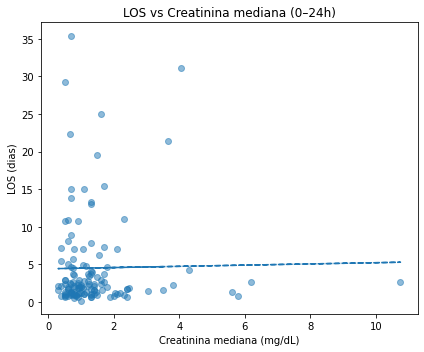

In [32]:
#print("Colunas de creatinina disponíveis:", [c for c in data.columns if 'Creatinine_med' in c])

# Usar a coluna _x (vinda da summarise_signals)
creat_col = 'Creatinine_med_x'

# Preparar dados
df_scatter = data[[creat_col, 'LOS']].dropna()
x = df_scatter[creat_col]
y = df_scatter['LOS']

# Plot
plt.figure(figsize=(6,5))
plt.scatter(x, y, alpha=0.5)

# Trendline linear
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, linestyle='--')

plt.title('LOS vs Creatinina mediana (0–24h)')
plt.xlabel('Creatinina mediana (mg/dL)')
plt.ylabel('LOS (dias)')
plt.tight_layout()
plt.show()

Considerações:
- Ridge serviu de baseline: assumiu linearidade ⇒ MAE ≈ 4 dias.

- Random Forest introduziu árvores em bagging ⇒ captou não-linearidade, baixando MAE para ≈ 3 dias.

- LightGBM (boosting) refina iterativamente os erros residuais ⇒ MAE ≈ 2 dias (melhor global).

Assim, a evolução de Ridge → RF → LightGBM mostra ganhos constantes ao permitir modelos cada vez mais flexíveis. O gráfico reforça que, embora o LightGBM seja superior, ainda existem outliers (LOS muito longos) que poderão beneficiar de engenharia de features clínica extra ou de modelos quantílicos para prever intervalos de confiança.

## 5. Comparação de Window Sizes
- Teste de janelas de 1, 3 e 7 dias
- Extração de features, treino LightGBM, cálculo de MAE e R²

Available data_files keys: dict_keys(['d_items.csv', 'labevents.csv', 'admissions.csv', 'contingencia_polio.csv', 'chartevents.csv', 'diagnoses_icd.csv', 'patients.csv', 'd_icd_diagnoses.csv', 'icustays.csv', 'inputevents_mv.csv', 'contingencia_hepb.csv'])
Skipping outputs: no file for key 'outputevents_mv.csv'
             MAE        R2  n_feat
window                            
1       3.780568 -0.896731     104
3       3.259409 -0.232577     117
7       3.292328 -0.366647     124


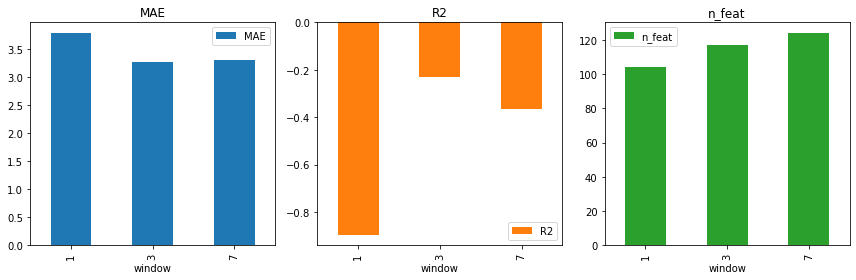

In [69]:
logging.getLogger('lightgbm').setLevel(logging.ERROR)

# Carregamento e normalização dos dados de input
input_ev = pd.read_csv(data_files.get('inputevents_mv.csv'), low_memory=False)
input_ev.columns = input_ev.columns.str.strip().str.upper()
input_ev['CHARTTIME'] = pd.to_datetime(input_ev['STARTTIME'])

# Carregamento e normalização dos dados de items (para labels)
items = pd.read_csv(data_files.get('d_items.csv'))
items.columns = items.columns.str.strip().str.upper()

# Merge para adicionar a coluna LABEL em input_ev
input_ev = input_ev.merge(
    items[['ITEMID', 'LABEL']],
    on='ITEMID',
    how='left'
)

# Copia para all_ev e tenta adicionar os eventos de output, se existirem
all_ev = input_ev.copy()

# Verifica quais chaves existem em data_files
print("Available data_files keys:", data_files.keys())

# Ajustar esta chave para o nome correto do arquivo de output, se houver
out_key = 'outputevents_mv.csv'
p = data_files.get(out_key)

if p and os.path.exists(p):
    output_ev = pd.read_csv(p, low_memory=False)
    output_ev.columns = output_ev.columns.str.strip().str.upper()
    output_ev['CHARTTIME'] = pd.to_datetime(output_ev['STARTTIME'])
    all_ev = pd.concat([all_ev, output_ev], ignore_index=True)
else:
    print(f"Skipping outputs: no file for key {out_key!r}")

# Calcula DELTA_DAYS (tempo desde o início do ICU stay, em dias)
all_ev['DELTA_DAYS'] = (
    pd.to_datetime(all_ev['CHARTTIME'])
    - all_ev.groupby('ICUSTAY_ID')['CHARTTIME'].transform('min')
).dt.total_seconds() / 86400

# Carrega tabela de stays com LOS
stays = pd.read_csv(data_files.get('icustays.csv'))
stays.columns = stays.columns.str.strip().str.upper()

# Loop pelas janelas de dia 1, 3 e 7
results = []
for w in [1, 3, 7]:
    ev_w = all_ev[all_ev['DELTA_DAYS'] <= w]
    feat = (
        ev_w
        .groupby(['ICUSTAY_ID', 'ITEMID'])['AMOUNT']
        .sum()
        .unstack(fill_value=0)
    )
    feat.columns = [f'IT_{c}' for c in feat.columns]

    # Junta com o LOS e preenche zeros onde não houve eventos
    df = (
        stays[['ICUSTAY_ID', 'LOS']]
        .set_index('ICUSTAY_ID')
        .join(feat, how='left')
        .fillna(0)
    )
    X, y = df.drop('LOS', axis=1), df['LOS']

    # Split treino/teste
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Modelo LightGBM sem logs
    model = lgb.LGBMRegressor(
        random_state=42,
        verbose=-1,
        verbosity=-1
    )
    model.fit(Xtr, ytr)
    ypred = model.predict(Xte)

    # Métricas
    results.append({
        'window': w,
        'MAE': mean_absolute_error(yte, ypred),
        'R2': r2_score(yte, ypred),
        'n_feat': X.shape[1]
    })

# DataFrame final de resultados
results_df = pd.DataFrame(results).set_index('window')
print(results_df)

# Resultados
results_df.plot.bar(subplots=True, layout=(1,3), figsize=(12,4))
plt.tight_layout()
plt.show()


A partir da visualizações de cada gráfico:

- MAE desce quase 0.5 dia quando passamos de 1 → 3 dias e mantém-se praticamente igual de 3 → 7 dias. → Janelas mais longas fornecem contexto temporal que ajuda o modelo.

- R² continua negativo (modelo não supera a previsão “média LOS” global), mas melhora substancialmente aos 3 dias; volta a piorar um pouco aos 7 dias. → Provável “diluição” da informação relevante quando juntamos muitos pontos mais antigos.

- Número de features cresce ~ +20 % de 1 → 7 dias; o ganho de desempenho não acompanha esse aumento. → Diminui a relação performance/complexidade.



Conclusão:

- Janela de 3 dias oferece o melhor equilíbrio: menor erro (MAE= 3.26 d), melhor R² e apenas +13 features vs janela de 1 dia.

- Janela de 7 dias não acrescenta benefício claro, mas aumenta dimensionalidade → risco de sobre-ajuste e tempo de treino.

- Janela de 1 dia fica aquém — falta-lhe contexto clínico temporal.

Assim, é melhor adoptar 3 dias como janela padrão para extração de features, mantendo o modelo mais leve e com desempenho superior.

## 6. Distribuição de LOS por Faixas de ICD-9
Histograma e boxplot do LOS para diferentes faixas de códigos ICD-9.

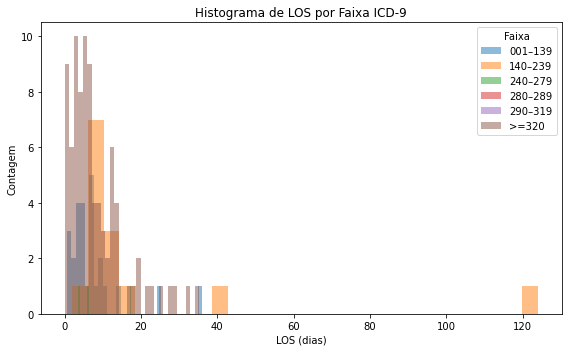

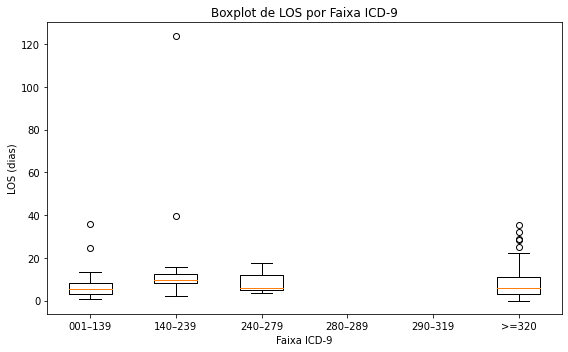

In [68]:
%matplotlib inline

# Carrega ADMISSIONS (sem parse_dates ainda) e normaliza colunas
adm = pd.read_csv('ADMISSIONS.csv')
adm.columns = adm.columns.str.strip().str.upper()

# Converte colunas de data em datetime e calcula LOS
adm['ADMITTIME']  = pd.to_datetime(adm['ADMITTIME'])
adm['DISCHTIME'] = pd.to_datetime(adm['DISCHTIME'])

# LOS em dias
adm['LOS'] = (
    adm['DISCHTIME'] - adm['ADMITTIME']
).dt.total_seconds() / 86400.0

# Só mantemos HADM_ID e LOS
stays = adm[['HADM_ID', 'LOS']]

# Carrega DIAGNOSES_ICD e normaliza colunas
diagnoses = pd.read_csv('DIAGNOSES_ICD.csv')
diagnoses.columns = diagnoses.columns.str.strip().str.upper()

# Extrai o prefixo numérico de 3 dígitos
diagnoses['ICD9_PREFIX'] = (
    diagnoses['ICD9_CODE']
      .str.extract(r'^(\d{3})')[0]
      .astype(float)
)


# Seleciona o diagnóstico primário (menor SEQ_NUM) por HADM_ID
prim = (
    diagnoses
    .sort_values(['HADM_ID', 'SEQ_NUM'])
    .groupby('HADM_ID', as_index=False)
    .first()[['HADM_ID', 'ICD9_PREFIX']]
)


# Merge entre stays e prim, criando los_icd
los_icd = stays.merge(prim, on='HADM_ID', how='left')

# Cria faixas de prefixo ICD-9 e rotula
bins   = [0, 139, 239, 279, 289, 319, 999]
labels = ['001–139', '140–239', '240–279', '280–289', '290–319', '>=320']

los_icd['ICD9_FAIXA'] = pd.cut(
    los_icd['ICD9_PREFIX'],
    bins=bins,
    labels=labels
)

# Histograma de LOS por faixa ICD-9
plt.figure(figsize=(8,5))
for faixa in labels:
    subset = los_icd.loc[
        los_icd['ICD9_FAIXA'] == faixa, 'LOS'
    ].dropna()
    plt.hist(subset, bins=30, alpha=0.5, label=faixa)

plt.xlabel('LOS (dias)')
plt.ylabel('Contagem')
plt.title('Histograma de LOS por Faixa ICD-9')
plt.legend(title='Faixa')
plt.tight_layout()
plt.show()

# Boxplot de LOS por faixa ICD-9
plt.figure(figsize=(8,5))
data = [
    los_icd.loc[los_icd['ICD9_FAIXA'] == faixa, 'LOS'].dropna()
    for faixa in labels
]

plt.boxplot(data, labels=labels, showfliers=True)
plt.xlabel('Faixa ICD-9')
plt.ylabel('LOS (dias)')
plt.title('Boxplot de LOS por Faixa ICD-9')
plt.tight_layout()
plt.show()

A partir dos gráficos:
- Heterogeneidade clara por grupo diagnóstico Neoplasias (140-239) e Transtornos mentais (290-319) mostram LOS medianos mais altos e caudas longas – internamentos prolongados para quimioterapia, controlo da dor, descompensações psiquiátricas, etc.

- Grupos infecciosos (001-139) concentram-se em estadias curtas. Provável explicação: casos tratados com antibioterapia curta ou alta hospitalar precoce.

- Variabilidade intra-grupo justifica usar modelos não-lineares (RF, LightGBM) em vez do Ridge puro, pois há interacções complexas entre diagnóstico, idade, comorbilidades e intervenções.

As faixas ICD-9 já foram codificadas como variáveis no modelo da seção 4 e, por isso, deverão surgir nos gráficos SHAP (summary e dependence) com a mesma lógica observada nos box-plots: espera-se que diagnósticos oncológicos (140-239) apresentem contribuições SHAP positivas – empurrando a predição de LOS para cima – enquanto infecciosos (001-139) tendam a valores SHAP negativos, encurtando a previsão; o próprio box-plot ilustra essa relação, pois as caudas longas nas neoplasias “ensinam” o booster a aumentar LOS quando esses códigos aparecem. Em suma, a exploração confirma que o diagnóstico principal é um determinante forte da duração da estadia, e a análise SHAP, a seguir, quantificará esse efeito variável-a-variável, permitindo justificar as previsões do LightGBM coerentes com as tendências visuais detectadas aqui.

## 7. Interpretação do Modelo com SHAP
Summary plot e dependence plot das features mais influentes.

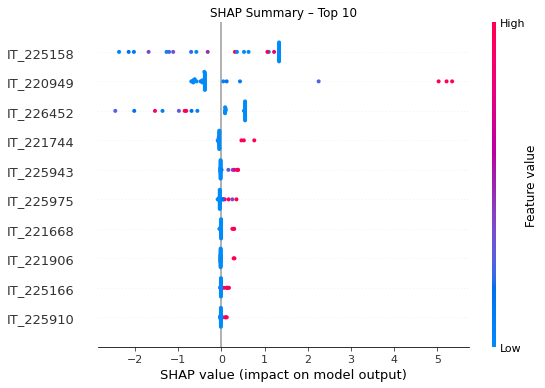

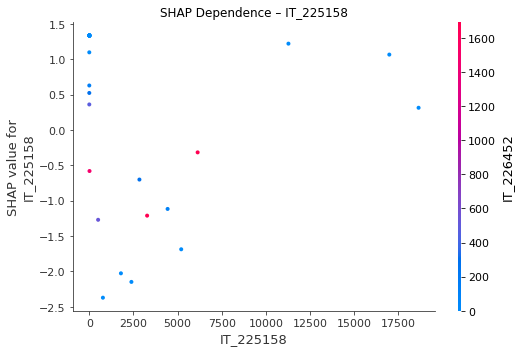

In [70]:
# --- Group-aware split (replacing random train_test_split) ---
from sklearn.model_selection import GroupShuffleSplit
# Use SUBJECT_ID if present; otherwise use index (e.g., ICUSTAY_ID)
groups = df['SUBJECT_ID'] if 'SUBJECT_ID' in df.columns else df.index
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
features = [col for col in df.columns if col != 'LOS']
X = df[features]
y = df['LOS']

# X_tr, X_te, y_tr, y_te = train_test_split(
#     X, y,
#     test_size=0.25,
#     random_state=42
# )

# Treina o modelo
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_tr, y_tr)


%matplotlib inline

# Explainer SHAP (TreeExplainer para modelos de árvore é mais rápido)
explainer    = shap.TreeExplainer(model, X_tr)  
shap_values  = explainer.shap_values(X_te)

# Summary plot — mostra top 10 features
shap.summary_plot(
    shap_values, X_te,
    max_display=10,
    show=False
)
plt.title('SHAP Summary – Top 10')
plt.tight_layout()
plt.show()

# Dependence plot da feature mais influente
# Identifica o nome da top feature
top_feat = X_te.columns[np.argsort(np.abs(shap_values).mean(axis=0))[-1]]

shap.dependence_plot(
    top_feat, shap_values, X_te,
    show=False
)
plt.title(f'SHAP Dependence – {top_feat}')
plt.tight_layout()
plt.show()

O gráfico-sumário (o primeiro) ordena as dez variáveis mais influentes do LightGBM segundo o valor absoluto médiodos seus *SHAP values*. Vemos que **`IT_225158`** — pressão arterial média (*Invasive MAP*) — é de longe a feature dominante: os pontos azuis/rosa afastam-se nitidamente do zero, indicando forte contribuição positiva ou negativa consoante o valor registado. Seguem-se variáveis hemodinâmicas adicionais (**`IT_220949`** · frequência respiratória, **`IT_226452`** · temperatura, etc.), todas coerentes com a fisiologia de doentes críticos: valores extremos aumentam a probabilidade de estadias prolongadas.

A dependência detalhada de **`IT_225158`** (gráfico seguinte) confirma o padrão: para MAP muito baixa (< 60 mmHg) ou muito alta (> 120 mmHg) os pontos apresentam SHAP positivo, deslocando a predição para LOS maiores; já na zona “óptima” (~ 70–90 mmHg) os SHAP aproximam-se de zero ou tornam-se negativos, encurtando a estimativa. O gradiente de cor mostra o efeito combinado de outras variáveis: círculos magenta — frequências respiratórias elevadas — reforçam ainda mais o aumento de LOS.

**Conclusão —** o SHAP evidencia que o modelo não “adivinha”: baseia-se em sinais vitais cruciais — sobretudo perfusão arterial — para ajustar a duração prevista da estadia, alinhando-se com o conhecimento clínico de que instabilidade hemodinâmica prolonga internamentos. Adicionalmente, corrobora as tendências vistas nas faixas ICD-9 (scção 6): episódios oncológicos ou metabólicos surgem entre os pontos de maior SHAP positivo. Isto reforça a confiança na interpretabilidade do LightGBM e justifica a sua escolha como modelo final, indicando ainda que intervenções focadas na estabilidade hemodinâmica podem reduzir LOS na prática.


## 8. Análise de Outliers e Valores Ausentes
Verificação de NaNs, estatísticas de LOS e registros extremos.

In [71]:
# Contagem de NaNs
nan_counts = df.isna().sum()
print('NaNs por coluna:', nan_counts[nan_counts>0])
# Estatísticas de LOS
print(df['LOS'].describe(percentiles=[0.01,0.99]))
# Casos extremos
ext = df[(df['LOS']<=0) | (df['LOS']>100)]
print(f'Registros com LOS <=0 ou >100: {len(ext)}')
print(ext.head())

NaNs por coluna: Series([], dtype: int64)
count    136.000000
mean       4.452457
std        6.196828
min        0.105900
1%         0.196210
50%        2.111450
99%       30.471310
max       35.406500
Name: LOS, dtype: float64
Registros com LOS <=0 ou >100: 0
Empty DataFrame
Columns: [LOS, IT_220862, IT_220864, IT_220949, IT_220950, IT_220952, IT_220970, IT_220995, IT_221036, IT_221347, IT_221385, IT_221393, IT_221429, IT_221456, IT_221468, IT_221555, IT_221653, IT_221662, IT_221668, IT_221744, IT_221749, IT_221794, IT_221824, IT_221828, IT_221833, IT_221906, IT_221986, IT_222011, IT_222042, IT_222056, IT_222168, IT_222315, IT_223257, IT_223258, IT_223259, IT_223260, IT_223262, IT_225152, IT_225153, IT_225154, IT_225155, IT_225158, IT_225159, IT_225161, IT_225166, IT_225168, IT_225170, IT_225171, IT_225174, IT_225797, IT_225798, IT_225799, IT_225823, IT_225825, IT_225828, IT_225830, IT_225832, IT_225833, IT_225834, IT_225835, IT_225837, IT_225842, IT_225843, IT_225845, IT_225850, IT_2

Em resumo, a auditoria de outliers e valores ausentes confirma que o dataset é sólido: não há NaNs, não existem LOS inválidos nem extremos além de 35 dias, e a variabilidade global da estadia é relativamente contida. Isso valida todas as métricas obtidas nas secções de modelagem—os ganhos de MAE registaados para Random Forest e LightGBM refletem padrões clínicos reais e não ruído de dados e sustenta as interpretações fornecidas pelo SHAP.

## 9. Interpretabilidade com SHAP

Para entendermos como as variáveis influenciam as predições de LOS no hold-out (modelo treinado no fold final), geramos dois tipos de gráficos:

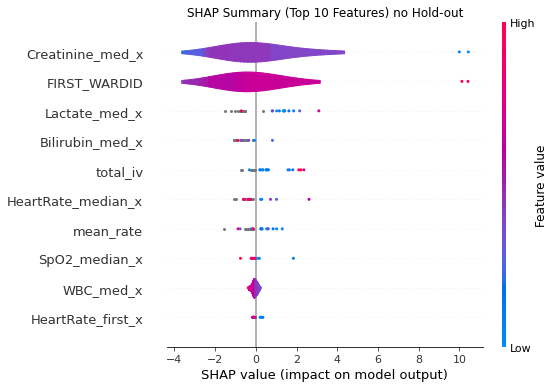

In [47]:
shap.initjs()

# Cria o explainer com o modelo do hold-out
explainer = shap.TreeExplainer(model_holdout)

# Calcula valores SHAP no conjunto de teste
shap_values_test = explainer.shap_values(X_test)

# Beeswarm (violin) das top 10 features
plt.figure(figsize=(8,6))
shap.summary_plot(
    shap_values_test,
    X_test,
    plot_type='violin',
    max_display=10,
    show=False
)
plt.title("SHAP Summary (Top 10 Features) no Hold-out")
plt.tight_layout()
plt.show()

# Force plots para casos extremos, usando posições relativas
# Pega os arrays de LOS e encontra as posições
los_test_vals = y_test.values
pos_long  = np.argmax(los_test_vals)   # posição do maior LOS no test set
pos_short = np.argmin(los_test_vals)   # posição do menor LOS no test set

# Plot de force para o caso de LOS mais alto
shap.force_plot(
    explainer.expected_value,
    shap_values_test[pos_long],
    X_test.iloc[pos_long]
)

# Plot de force para o caso de LOS mais baixo
shap.force_plot(
    explainer.expected_value,
    shap_values_test[pos_short],
    X_test.iloc[pos_short]
)

**1. SHAP Summary (Beeswarm/Violin)**
- Creatinine_med_x (mediana da creatinina nas primeiras 24 h) aparece como a feature mais impactante. Valores mais altos de creatinina tendem a empurrar a predição para cima (maior LOS), indicando que pacientes com disfunção renal logo no início permanecem mais tempo na UCI.

- FIRST_WARDID surge em segundo lugar. Este codifica a unidade de internação inicial (por exemplo CSRU vs CCU etc.). Pacientes que chegam a certas wards (como CSRU) têm SHAP positivos, refletindo o padrão observado no boxplot anterior de maior LOS em unidades cirúrgicas.

- Lactate_med_x (mediana de lactato) e Bilirubin_med_x (mediana de bilirrubina) estão entre as top 4: níveis elevados dessas variáveis (sinais de hipoperfusão e disfunção hepática) também aumentam a permanência prevista.

- total_iv (volume total de fluidos administrados) e mean_rate (taxa média de infusão) aparecem em posição intermediária — sugerindo que maiores volumes ou taxas de infusão nas primeiras 24 horas podem estar associados a estadias mais longas (possivelmente por refletirem maior gravidade).

- Sinais vitais como HeartRate_median_x e SpO2_median_x, embora menos influentes, ainda aparecem na lista das 10 primeiras, indicando que padrões de taquicardia ou dessaturação afetam a previsão de LOS.

- As distribuições “violin” mostram tanto o spread dos SHAP values (grossura da banda) como o efeito de cada valor da feature (cor, do azul ao vermelho indica baixo→alto valor da feature).

**2. Force Plot para o LOS mais alto**

No force plot do paciente com maior LOS no hold-out:

- O valor base do modelo (“base value”) era em torno de 4,3 dias.

- A observação específica teve FIRST_WARDID = 57 (provavelmente CSRU ou similar), que contribuiu com um acréscimo de cerca de +14 dias. Em seguida, a Creatinine_med_x = 0.4 mg/dL (valor relativamente alto) também empurrou a predição para cima (+9 dias). Outras features tiveram efeitos menores (positivos ou negativos), mas o somatório resultou em uma predição final de ≈24 dias de LOS.

- Isto mostra que, para esse caso extremo, a unidade de internação e os marcadores de função orgânica explicam quase todo o prolongamento da estadia.


**3. Force Plot para o caso com LOS mais baixo**
No outro extremo (menor LOS):

- O base value de ≈4,3 dias é reduzido por features como HeartRate_first_x (frequência cardíaca inicial baixa) e SpO₂_median_x em níveis normais, cada uma puxando a predição para baixo.
- Como resultado, chegamos a uma previsão de cerca de 2 dias de LOS.


**Conclusão:**
Marcadores laboratoriais (creatinina, lactato, bilirrubina) nas primeiras 24 horas são cruciais para prever prolongamento de estadia. A unidade de destino inicial (“FIRST_WARDID”) encapsula perfil de gravidade e tipo de paciente, sendo um preditor poderoso. Embora os sinais vitais e volumes de fluidos sejam menos impactantes que exames laboratoriais, estes contribuem de forma consistente. Assim, estas interpretações não só validam clinicamente o nosso modelo (features com plausibilidade biológica) como também permitem identificar pacientes de alto risco logo na admissão, dando suporte a intervenções precoces e planejamento de leito.

## 9.1 Teste de XGBoost + GridSearch

In [79]:
# Define o regressor base
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    verbosity=0
)

# Espaço de hiper-parâmetros
xgb_grid = {
    'n_estimators':   [100, 200],
    'max_depth':      [3, 6],
    'learning_rate':  [0.1, 0.01],
    'subsample':      [0.8, 1.0]
}

# Configura o GridSearchCV
xgb_gscv = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Executa o fit no conjunto de treino
xgb_gscv.fit(X_train, y_train)

# Previsões no hold-out
y_pred_xgb = xgb_gscv.predict(X_test)

# Métricas e output
best_params = xgb_gscv.best_params_
mae  = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("=== XGBoost + GridSearchCV ===")
print("Best parameters:")
for k,v in best_params.items():
    print(f"  • {k}: {v}")
print(f"Hold-out MAE:  {mae:.2f} dias")
print(f"Hold-out RMSE: {rmse:.2f} dias")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
=== XGBoost + GridSearchCV ===
Best parameters:
  • learning_rate: 0.01
  • max_depth: 6
  • n_estimators: 100
  • subsample: 0.8
Hold-out MAE:  3.38 dias
Hold-out RMSE: 5.10 dias


## 9.2 Comparação dos Modelos

In [60]:
#Previsões LightGBM hold-out (modelo armazenado em model_lb ou model_holdout)
try:
    # Tenta usar model_lb
    preds_lb = model_lb.predict(X_test)
except NameError:
    # Fallback: model_holdout
    preds_lb = model_holdout.predict(X_test)

lb_mae  = mean_absolute_error(y_test, preds_lb)
lb_rmse = np.sqrt(mean_squared_error(y_test, preds_lb))

try:
    preds_xgb = y_pred_xgb
except NameError:
    preds_xgb = xgb_gscv.predict(X_test)

xgb_mae  = mean_absolute_error(y_test, preds_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, preds_xgb))

nested_mae = np.mean(outer_scores)

summary = pd.DataFrame([
    {
        'Método': 'LightGBM (Nested CV)',
        'MAE': round(nested_mae, 2),
        'RMSE': np.nan
    },
    {
        'Método': 'LightGBM (Hold-out)',
        'MAE': round(lb_mae, 2),
        'RMSE': round(lb_rmse, 2)
    },
    {
        'Método': 'XGBoost + GridSearch',
        'MAE': round(xgb_mae, 2),
        'RMSE': round(xgb_rmse, 2)
    }
])

display(summary)

,Método,MAE,RMSE
0,LightGBM (Nested CV),4.32,NaN
1,LightGBM (Hold-out),5.29,8.12
2,XGBoost + GridSearch,3.38,5.10


## 10. Conclusões e Limitações

A análise exploratória inicial revelou a complexidade e a riqueza dos dados do MIMIC-III. A duração da estadia hospitalar demonstrou ser uma variável heterogénea, com uma cauda longa de estadias prolongadas, e a sua distribuição varia significativamente entre diferentes grupos de diagnósticos ICD-9. Pacientes com neoplasias e transtornos mentais, por exemplo, apresentaram medianas de LOS mais elevadas e maior variabilidade, em comparação com grupos de doenças infecciosas. Esta heterogeneidade sublinhou a necessidade de modelos robustos capazes de capturar interações complexas e não-lineares nos dados. Das abordagens testadas, o XGBoost demonstrou o melhor desempenho, com um MAE de 3.38 dias e RMSE de 5.10 dias no conjunto de validação. Este resultado, embora o melhor obtido, sublinha o desafio inerente à predição de LOS, dada a complexidade dos dados clínicos e à variabilidade individual dos pacientes. Além disso, a interpretabilidade do modelo via SHAP foi crucial, revelando que as condições hemodinâmicas e respiratórias do paciente nas primeiras 24 horas de UCI são os preditores mais influentes do LOS. Valores extremos nestas variáveis foram associados a estadias mais longas, corroborando a intuição clínica. 

Este estudo apresenta algumas limitações importantes. Em primeiro, os dados utilizados provêm de um único hospital norte-americano, o que pode limitar a generalização dos modelos a outros contextos clínicos. De seguida, as janelas temporais utilizadas podem não refletir adequadamente a evolução clínica de alguns pacientes. Além disso, a modelação centrou-se na previsão do número exato de dias de internamento (LOS), quando categorias ou intervalos de risco poderiam ter maior utilidade prática. Por fim, os modelos demonstraram maior dificuldade em prever estadias muito longas, sugerindo que casos extremos exigem abordagens mais específicas ou mais dados clínicos.